# Intro to Agentic AI

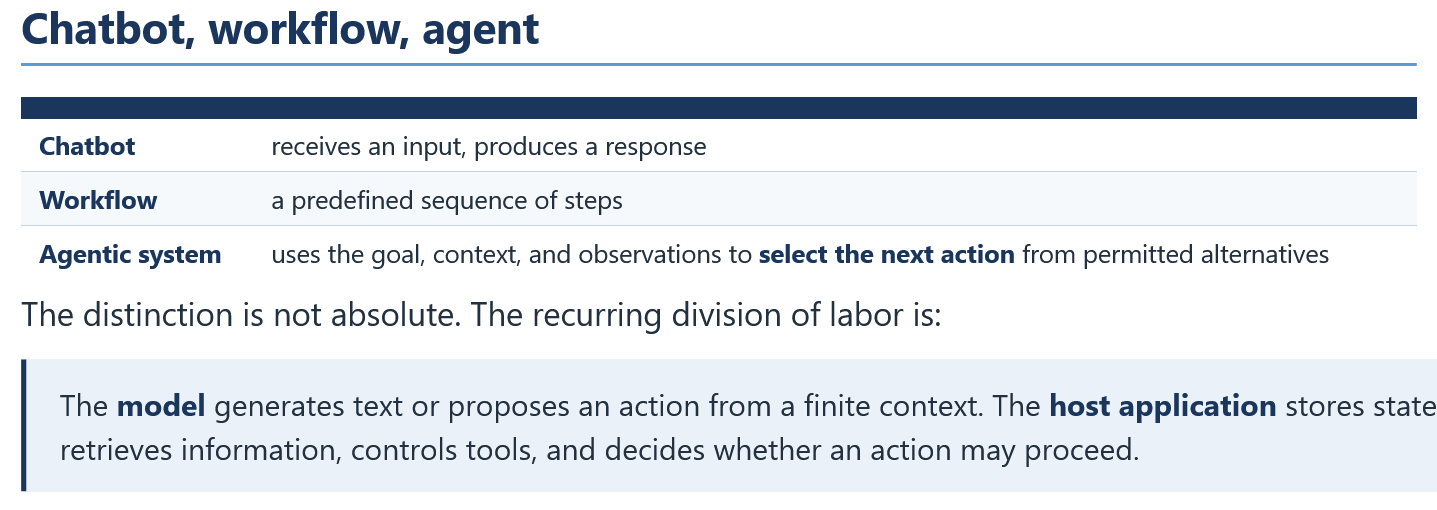

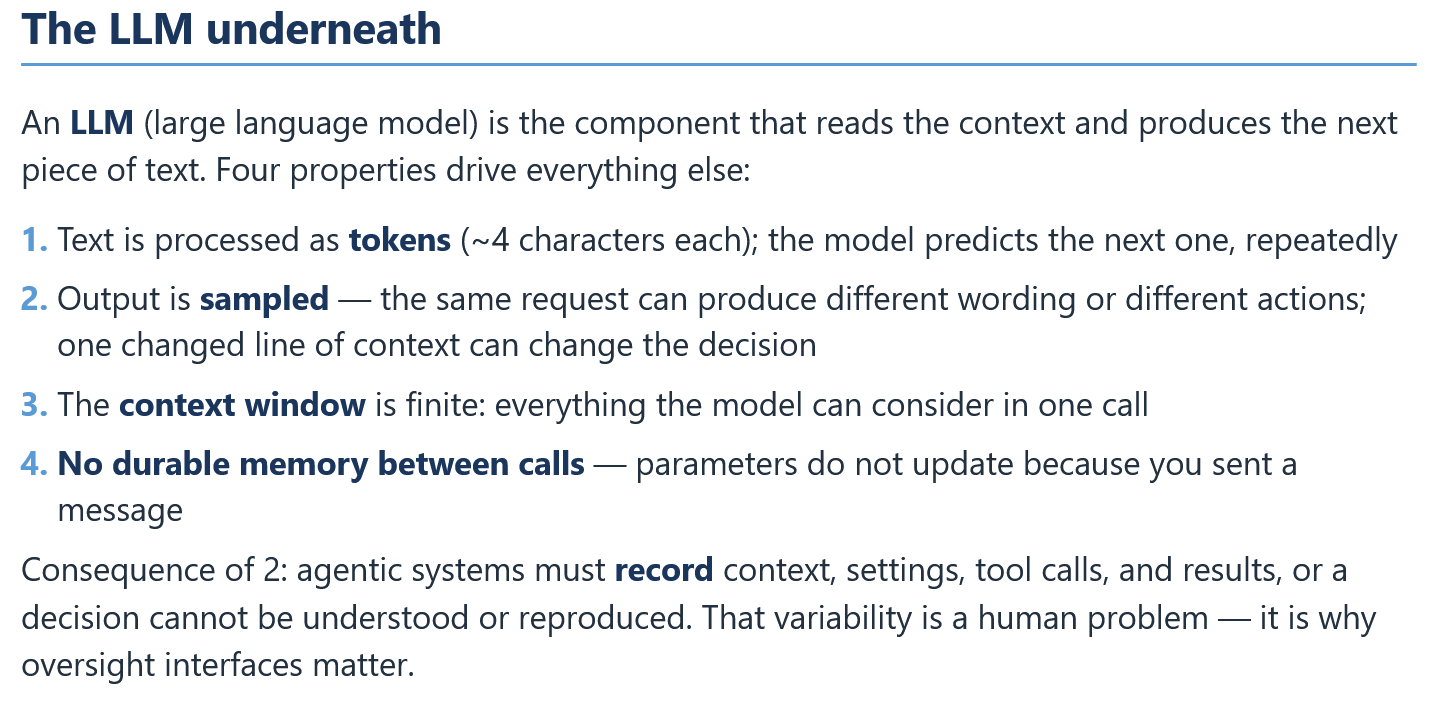



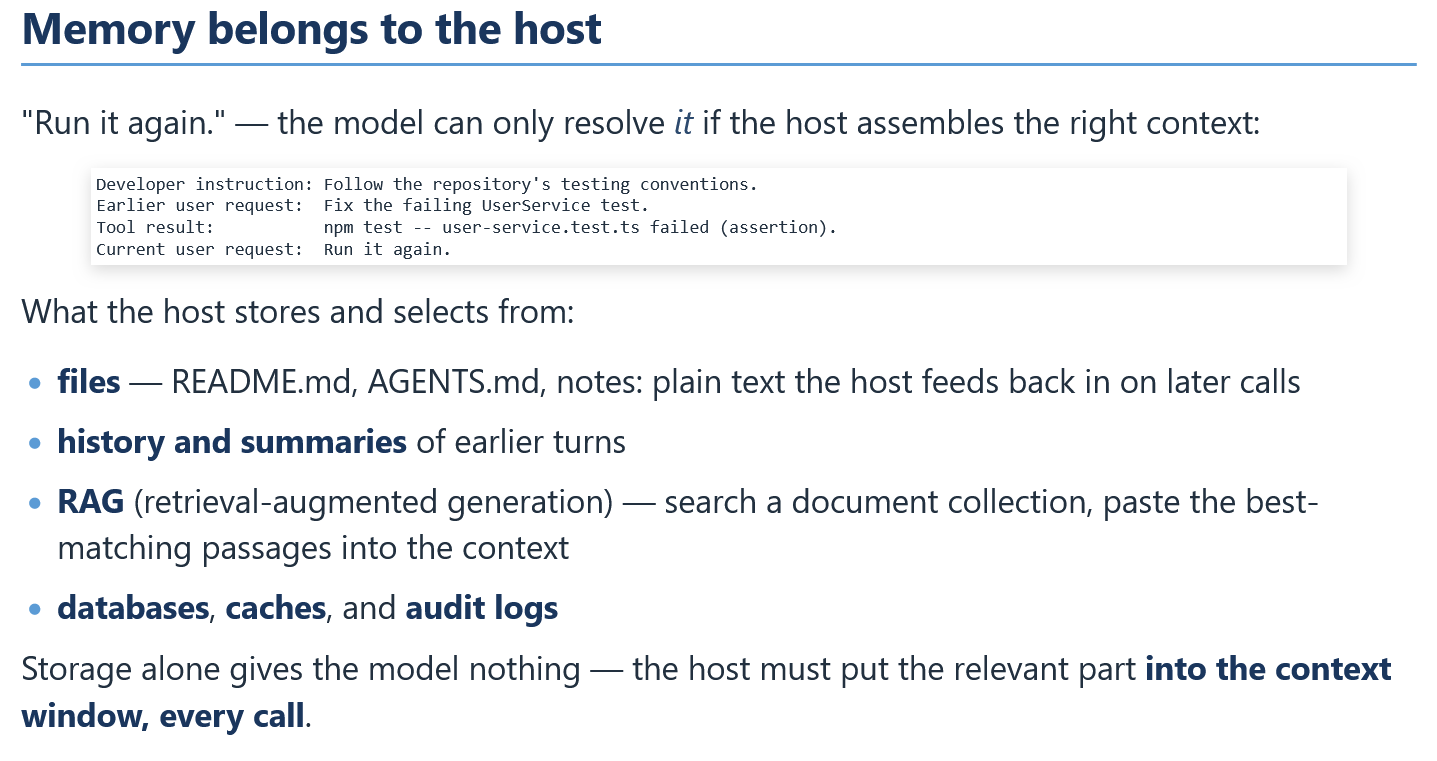


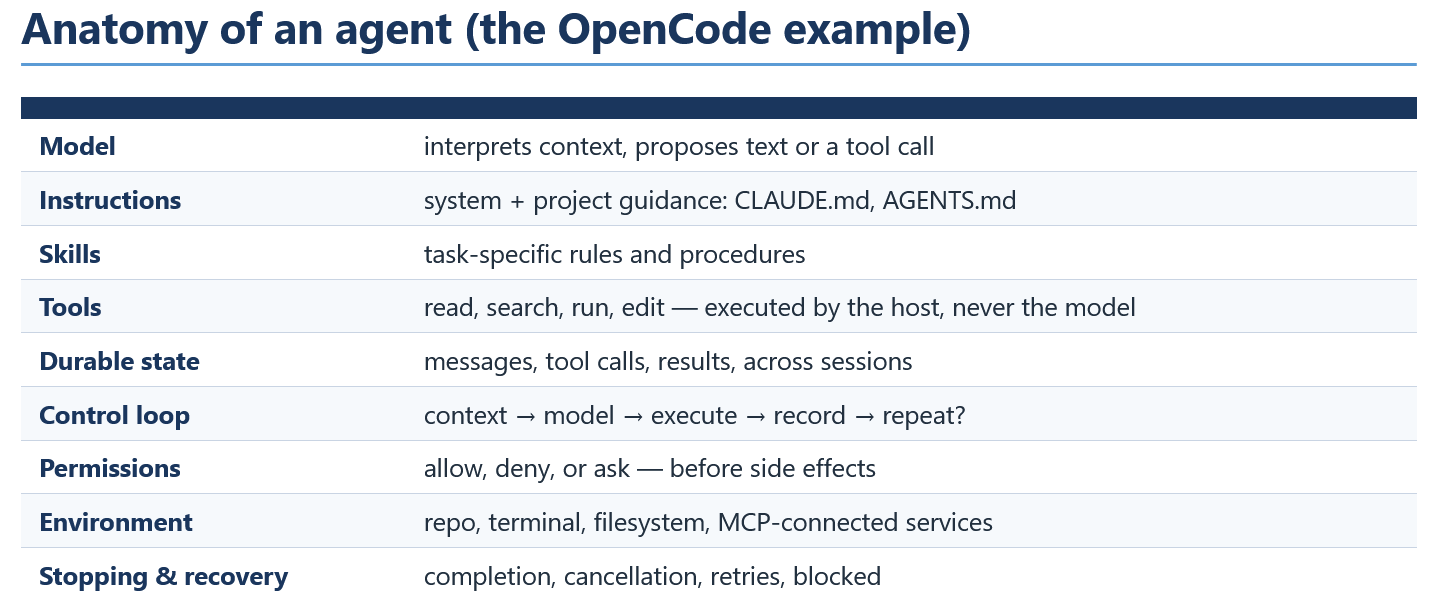


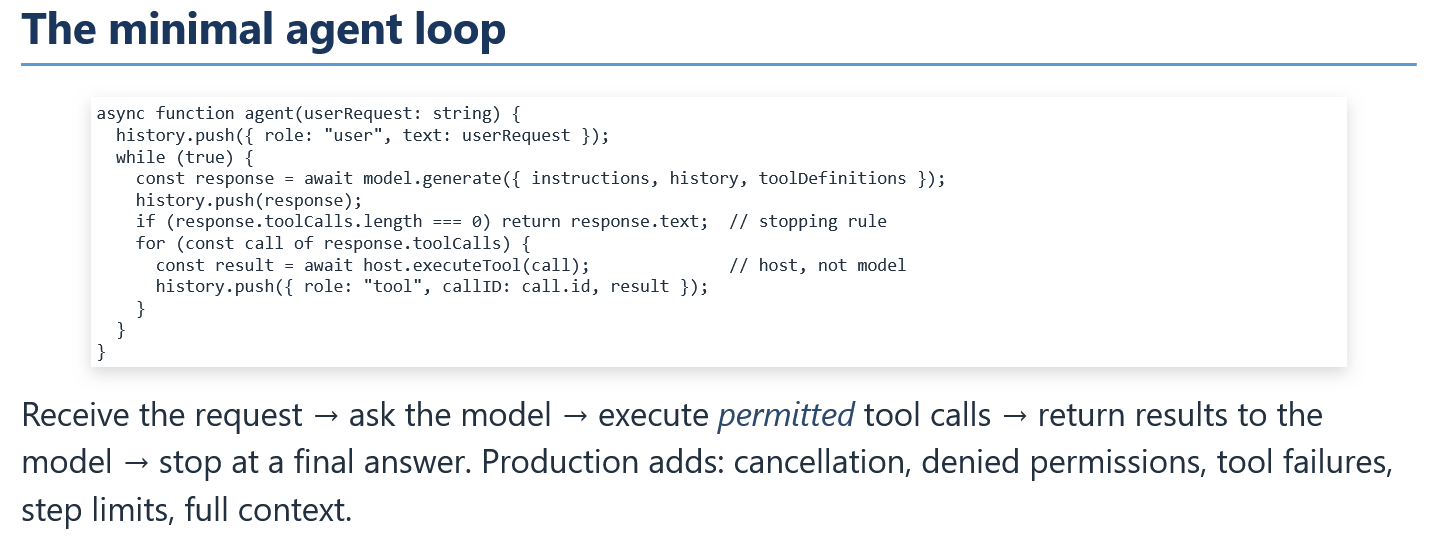

Analysis:

`async function agent(userRequest: string) { ` defines the asynchronous entry point for the agent accepting a text string representing the initial query

`history.push({ role: "user", text: userRequest });` initializes the conversation state by appending the user query to the history array.

`while true loop begins`

`const response = await model.generate({ instructions, history, toolDefinitions });` invokes the language model. The model receives system instructions, the current conversation state, and the definitions of available tools it can choose to execute.

`history.push(response);` saves the generation back to the state array. This is critical because the history must reflect that the model requested a tool before the subsequent tool output is provided.

`if (response.toolCalls.length === 0) return response.text;` // stopping rule acts as the exit condition. If the model determines it has sufficient information to answer the user without calling more tools, it returns the final text and breaks the infinite loop.

`for (const call of response.toolCalls) {` iterates through every tool execution requested in the current generation cycle.

`const result = await host.executeTool(call);` // host, not model pauses to execute the requested tool in the host environment. The inline comment explicitly notes this runs on the host machine, completely separate from the model infrastructure.

`history.push({ role: "tool", callID: call.id, result });` appends the precise result of the executed tool back to the conversation array. On the next iteration of the while loop, the model will read this result to decide its next action.

The remaining three brackets sequentially close the for loop, the while loop, and the function block.






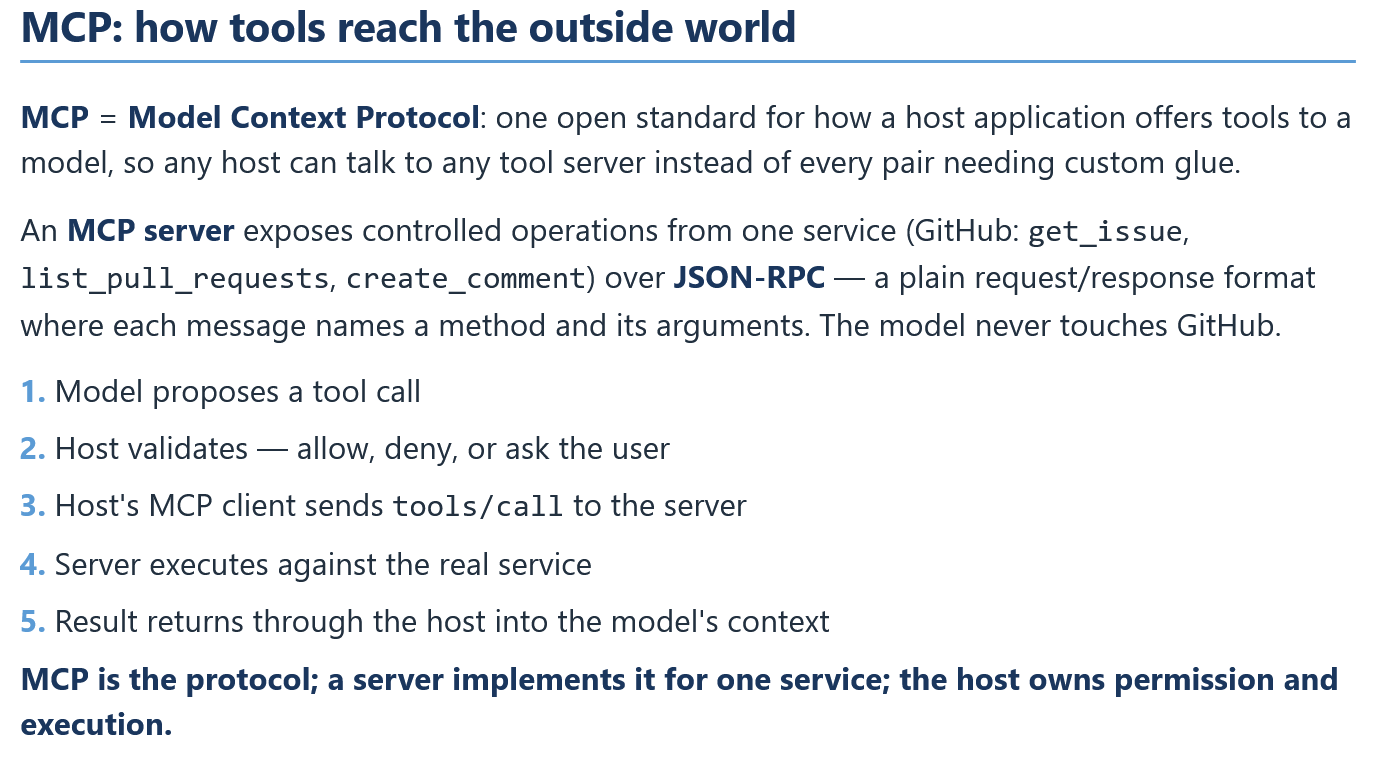

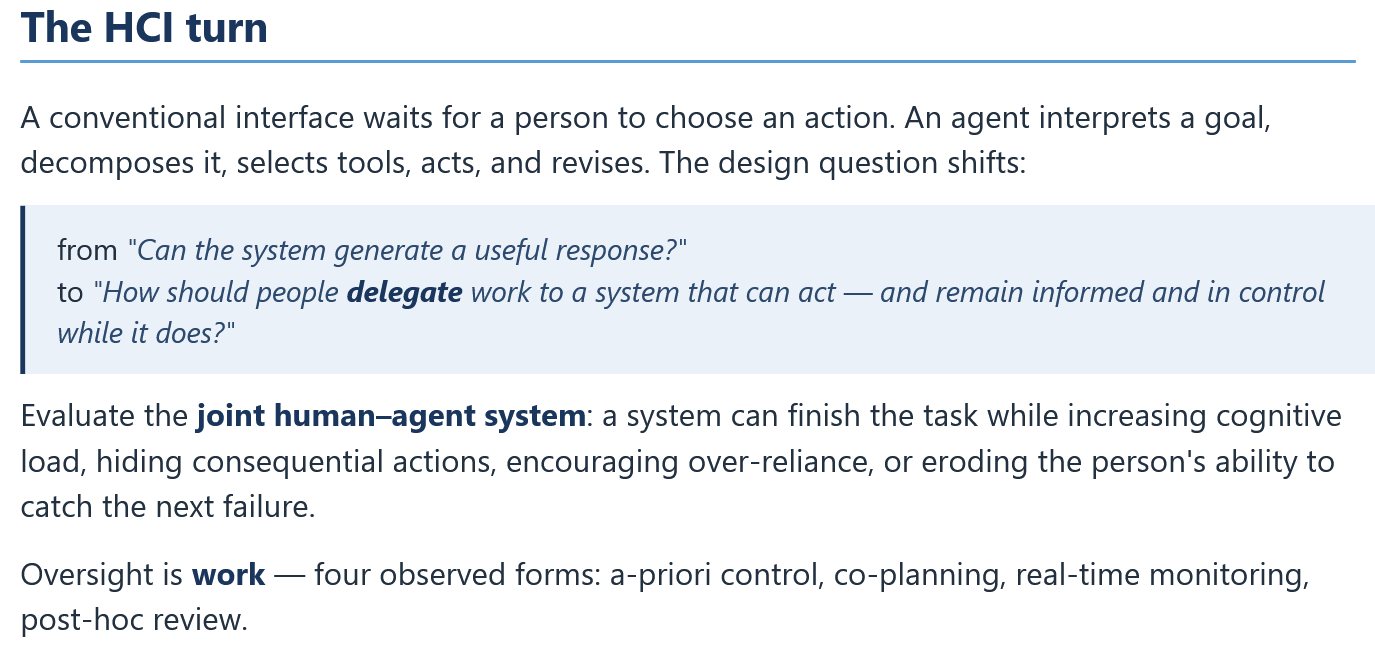

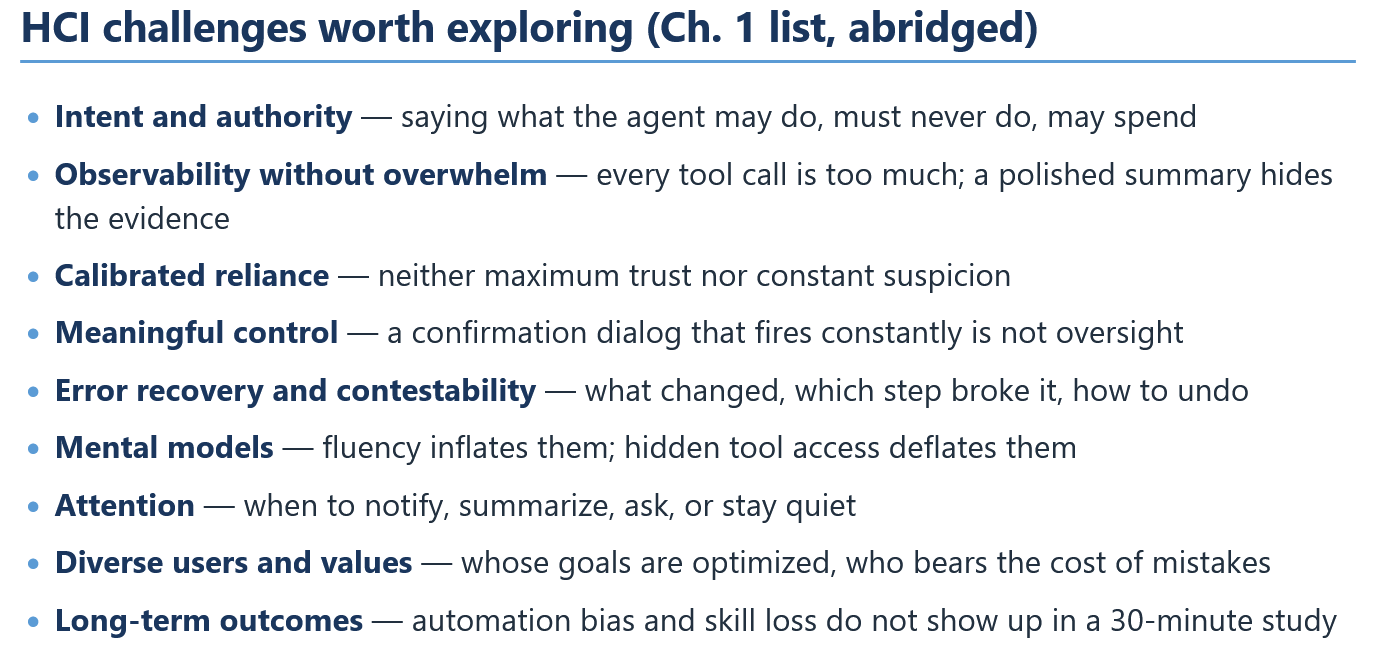



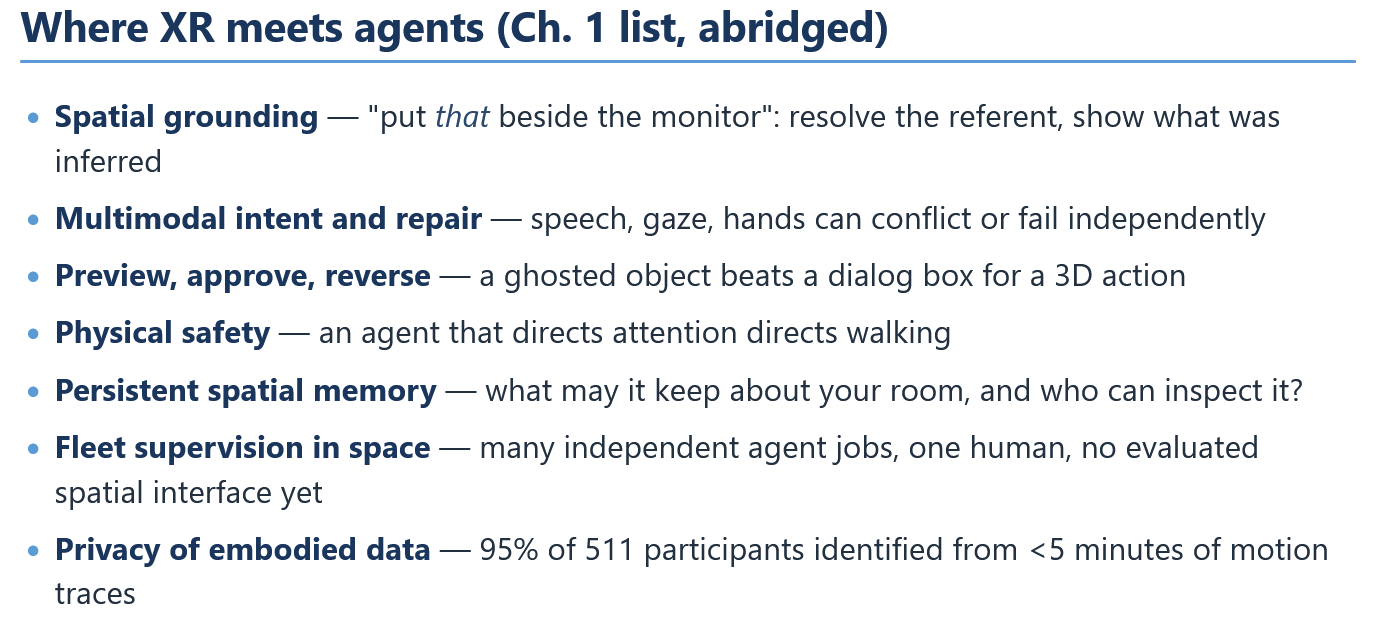

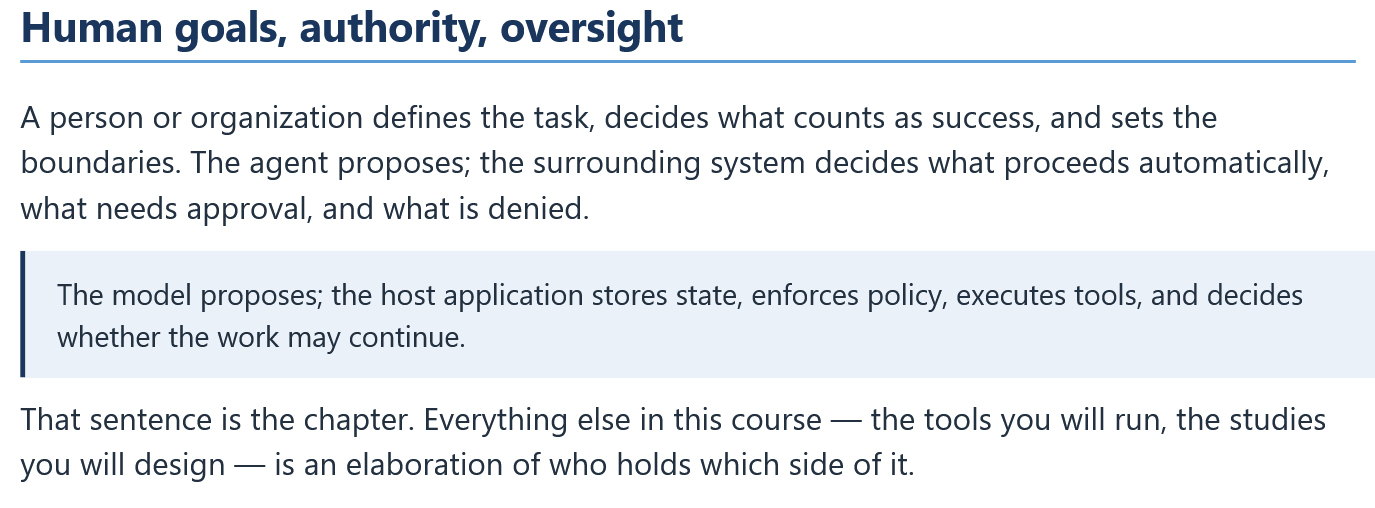